<a href="https://colab.research.google.com/github/WNderitu/data_science_capstone_project/blob/main/Malaria_parasite_detector_and_counter_augmented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Plasmodium Vivax (malaria) parasite detector and counter**


## **1.0 Introduction**

Malaria, a life-threatening disease caused by Plasmodium parasites transmitted by female Anopheles mosquitoes, is most commonly found in tropical and subtropical regions. In 2023, the African Region was home to 94% and 95% of malaria cases and deaths, respectively. Sub-Saharan Africa carries a disproportionately high share of the global malaria burden. Plasmodium vivax is one of the 5 parasites that cause malaria associated with disease relapses due to dormant liver stages, contributing significantly to morbidity.

The Plasmodium vivax lifecycle alternates between humans and Anopheles mosquitoes. Infection begins when a mosquito injects sporozoites into a human, which then move to the liver to either develop or remain dormant. Merozoites released from the liver infect red blood cells, progressing through ring, trophozoite, and schizont stages, causing malaria symptoms. Some parasites develop into gametocytes, enabling further transmission via mosquitoes.

Diagnosis of Plasmodium vivax malaria relies on examining stained blood smears via microsocopy and rapid diagnostic tests, with accurate detection being key to effective treatment and relapse prevention. Advanced methods like deep learning models, such as Regional Based CNN, YOLOv8, and others would offer improved reliability and efficiency in identifying infections.

## **1.1 Problem Statement**

The detection of Plasmodium vivax malaria remains challenging, primarily due to the morphological similarities between parasite stages and other blood components observed in microscopic images. Conventional microscopy is a labor-intensive process that is susceptible to human error and demands specialized expertise, which may be limited in under-resourced settings. Consequently, there is an urgent need for automated, efficient, and dependable solutions capable of detecting and quantifying Plasmodium vivax parasites and their developmental stages within blood smears. Such advancements would enhance diagnostic accuracy, promote effective treatment, and strengthen malaria control initiatives.

## **1.2 Objectives**



1.   To develop a computer vision model for object detection and counting
2.   To detect uninfected red blood cells and leukocytes in human blood cells in a microscopic image from a blood smear using the developed YOLOv8 model
3. To count the number of uninfected red blood cells and leukocytes in human blood cells in a microscpic image from a blood smear using the developed YOLOv8 model
4. To detect the growth stage of a Plasmodium Vivax (malaria parasite) in human blood cells in a microscopic image from a blood smear using the developed YOLOv8 model
5. To count the number of detected growth stages of the plasmodium vivax parasites per microscopic image using the developed YOLOv8 model

## **1.3 Installing & Importing Required Libraries**

In [ ]:
!pip install matplotlib

In [ ]:
!pip install Pillow #installing PILLOW LIBRARY

In [ ]:
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.5 MB/s eta 0:00:00


In [ ]:
!pip install pyyaml

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.4 MB/s eta 0:00:00


In [ ]:
import requests
import os
import json
import random
import shutil
from pprint import pprint # for
import PIL
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from collections import Counter
import hashlib # find identical images
from collections import defaultdict
import numpy as np
import math # for
import yaml
from collections import Counter # Import Counter to get class counts
import shutil # for creating directories

## **1.4 Image dataset**

Dataset sourced from: https://bbbc.broadinstitute.org/BBBC041/

The dataset consists of:

image folder

training json file

test json file

The dataset consists of 1,328 microscopic images of blood smears

### **1.4.1 Downloading image dataset from website**

In [ ]:
url = "https://bbbc.broadinstitute.org/BBBC041/"
response = requests.get(url)

if response.status_code == 200:
    print("Successfully accessed the URL.") # Parse the HTML content here to find the actual data file links.
else:
    print(f"Failed to access the URL. Status code: {response.status_code}")

Successfully accessed the URL.


In [ ]:
from bs4 import BeautifulSoup
# Use BeautifulSoup & find links to data files and download them.

# Assuming 'response' from the previous cell contains the HTML content
if 'response' in locals() and response.status_code == 200:
    soup = BeautifulSoup(response.content, 'html.parser')

    # Find all links on the page
    links = soup.find_all('a')

    # Filter for links that seem to be data files (e.g., ending with .zip, .csv, etc.)
    # This is a generic approach and might need adjustment based on the actual website structure
    data_links = [link.get('href') for link in links if link.get('href') and (link.get('href').endswith('.zip') or link.get('href').endswith('.csv'))]

    # Create a directory to save the downloaded files if it doesn't exist
    download_dir = "downloaded_data"
    os.makedirs(download_dir, exist_ok=True)

    print(f"Found {len(data_links)} potential data files.")

    # Download each data file
    for data_link in data_links:
        # Construct the full URL if the link is relative
        if not data_link.startswith('http'):
            full_url = url + data_link
        else:
            full_url = data_link

        file_name = os.path.join(download_dir, os.path.basename(full_url))

        try:
            print(f"Downloading {full_url} to {file_name}...")
            with requests.get(full_url, stream=True) as r:
                r.raise_for_status()
                with open(file_name, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
            print("Download complete.")
        except requests.exceptions.RequestException as e:
            print(f"Error downloading {full_url}: {e}")

else:
    print("Could not proceed with downloading data. Please ensure the previous cell successfully accessed the URL.")

Found 1 potential data files.
Download complete.


In [ ]:
from google.colab import drive

# Mount Google Drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

Error mounting Google Drive: Mountpoint must not already contain files


In [ ]:
# Define source and destination paths
zip_file_path = 'downloaded_data/malaria.zip'
# Define the destination path in your Google Drive
# You might want to change 'malaria_dataset' to a specific folder name in your Drive
destination_path = '/content/drive/MyDrive/malaria_dataset/malaria.zip'

# Create the destination directory if it doesn't exist
destination_dir = os.path.dirname(destination_path)
os.makedirs(destination_dir, exist_ok=True)
print(f"Created destination directory in Google Drive: {destination_dir}")

# Copy the zip file to Google Drive
try:
    shutil.copy(zip_file_path, destination_path)
    print(f"Successfully copied {zip_file_path} to {destination_path}")
except FileNotFoundError:
    print(f"Error: The source file {zip_file_path} was not found.")
except Exception as e:
    print(f"An error occurred while copying the file: {e}")

Error mounting Google Drive: Mountpoint must not already contain files
Created destination directory in Google Drive: /content/drive/MyDrive/malaria_dataset
Successfully copied downloaded_data/malaria.zip to /content/drive/MyDrive/malaria_dataset/malaria.zip


### **1.4.2 Extract contents of downloaded zip file & inspect structure of image dataset files**

In [ ]:
# extract contents of zip file
import zipfile

zip_file_path_drive = '/content/drive/MyDrive/malaria_dataset/malaria.zip'
extract_dir_drive = '/content/drive/MyDrive/malaria_dataset/malaria_extracted'

# Create the extraction directory in Google Drive if it doesn't exist
os.makedirs(extract_dir_drive, exist_ok=True)
print(f"Created extraction directory in Google Drive: {extract_dir_drive}")


try:
    with zipfile.ZipFile(zip_file_path_drive, 'r') as zip_ref:
        zip_ref.extractall(extract_dir_drive)
    print(f"Successfully extracted {zip_file_path_drive} to {extract_dir_drive}")
except FileNotFoundError:
    print(f"Error: The zip file was not found at {zip_file_path_drive}.")
except zipfile.BadZipFile:
    print(f"Error: The file {zip_file_path_drive} is not a valid zip file.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

Created extraction directory in Google Drive: /content/drive/MyDrive/malaria_dataset/malaria_extracted
Successfully extracted /content/drive/MyDrive/malaria_dataset/malaria.zip to /content/drive/MyDrive/malaria_dataset/malaria_extracted


In [ ]:
# List the contents of the 'malaria_extracted' directory
extract_dir_drive = '/content/drive/MyDrive/malaria_dataset/malaria_extracted'

try:
    extracted_contents = os.listdir(extract_dir_drive)
    print(f"Contents of {extract_dir_drive}:")
    pprint(extracted_contents)
except FileNotFoundError:
    print(f"Error: The directory was not found at {extract_dir_drive}")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of /content/drive/MyDrive/malaria_dataset/malaria_extracted:
['__MACOSX', 'malaria']


In [ ]:
# List the contents of the 'malaria' directory in malaria_extracted
malaria_dir = os.path.join(extract_dir_drive, 'malaria')

try:
    malaria_contents = os.listdir(malaria_dir)
    print(f"Contents of {malaria_dir}:")
    pprint(malaria_contents) # Add closing parenthesis and pprint for better display
except FileNotFoundError:
    print(f"Error: The directory was not found at {malaria_dir}")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria:
['test.json', 'training.json', 'images']


In [ ]:
# rename training json to train json
old_name = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/training.json'
new_name = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/train.json'

try:
    os.rename(old_name, new_name)
    print(f"Successfully renamed {old_name} to {new_name}")
except FileNotFoundError:
    print(f"Error: The source file {old_name} was not found.")
except FileExistsError:
    print(f"Error: The destination file {new_name} already exists.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully renamed /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/training.json to /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/train.json


In [ ]:
# Check contents of train json file
train_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/train.json'

try:
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)

    print(f"Contents of {train_json_path} (first entry):")
    if train_data:
        pprint(train_data[0])
    else:
        print("The train.json file is empty.")

except FileNotFoundError:
    print(f"Error: The file {train_json_path} was not found.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {train_json_path}. Please check the file format.")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/train.json (first entry):
{'image': {'checksum': '676bb8e86fc2dbf05dd97d51a64ac0af',
           'pathname': '/images/8d02117d-6c71-4e47-b50a-6cc8d5eb1d55.png',
           'shape': {'c': 1600, 'channels': 3, 'r': 1200}},
 'objects': [{'bounding_box': {'maximum': {'c': 1540, 'r': 1158},
                               'minimum': {'c': 1440, 'r': 1057}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1403, 'r': 971},
                               'minimum': {'c': 1303, 'r': 868}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1008, 'r': 689},
                               'minimum': {'c': 900, 'r': 578}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 713, 'r': 408},
                               'minimum': {'c': 611, 'r': 304}},
              'category': 'red blood cell'},


The train.json file contains annotations for different objects within the images, including their categories and bounding boxes as a list. Each entry represents an image and it's annotations and is a dictionary with two main keys:

- **'image'**: This dictionary contains information about the image, such as:
  - **'checksum'**: A unique identifier for the image file
  - **'pathname'**: The path to the image file (relative to the dataset's image directory).
  - **'shape'**: The dimensions of the image (columns c and rows r), and the number of channels.

- **'objects'**: This is a list of dictionaries, where each dictionary represents a detected object within the image. Each object dictionary contains:
  - **'bounding_box'**: A dictionary specifying the coordinates of the bounding box around the object. It has:
      - **'maximum'**: A dictionary with the maximum column (c) and row (r) coordinates of the bounding box.
      - **'minimum'**: A dictionary with the minimum column (c) and row (r) coordinates of the bounding box.
  - **'category'**: A string indicating the class or type of the object detected (e.g., 'red blood cell', 'trophozoite').

In [ ]:
# Check contents of test json file
test_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/test.json'

try:
    with open(test_json_path, 'r') as f:
        test_data = json.load(f)

    print(f"Contents of {train_json_path} (first entry):")
    if test_data:
        pprint(test_data[0])
    else:
        print("The test.json file is empty.")

except FileNotFoundError:
    print(f"Error: The file {test_json_path} was not found.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {test_json_path}. Please check the file format.")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/train.json (first entry):
{'image': {'checksum': 'eea3bfd6a929bcb06f9786667cd3fbb2',
           'pathname': '/images/41be1bd3-0d31-4881-bf1f-3ccdfa21ff12.jpg',
           'shape': {'c': 1944, 'channels': 3, 'r': 1383}},
 'objects': [{'bounding_box': {'maximum': {'c': 1883, 'r': 708},
                               'minimum': {'c': 1744, 'r': 576}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1373, 'r': 977},
                               'minimum': {'c': 1249, 'r': 863}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1711, 'r': 335},
                               'minimum': {'c': 1573, 'r': 210}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1253, 'r': 1142},
                               'minimum': {'c': 1124, 'r': 1017}},
              'category': 'red blood cell'

same as for train json file

In [ ]:
# Get number of test and train images

# Assuming train_data and test_data are available from previous cell executions
if 'train_data' in locals():
    num_train_images = len(train_data)
    print(f"Number of images in the train dataset: {num_train_images}")
else:
    print("Train data not loaded. Please run the cell that loads 'train.json'.")
    num_train_images = 0

if 'test_data' in locals():
    num_test_images = len(test_data)
    print(f"Number of images in the test dataset: {num_test_images}")
else:
    print("Test data not loaded. Please run the cell that loads 'test.json'.")
    num_test_images = 0

total_images = num_train_images + num_test_images

if total_images > 0:
    train_proportion = num_train_images / total_images
    test_proportion = num_test_images / total_images
    print(f"\nProportion of train images: {train_proportion:.2f}")
    print(f"Proportion of test images: {test_proportion:.2f}")
else:
    print("\nNo images loaded to calculate proportions.")

Number of images in the train dataset: 1208
Number of images in the test dataset: 120

Proportion of train images: 0.91
Proportion of test images: 0.09


In [ ]:
# 3. Create Validation Directory
# Create a new directory for the validation images and their corresponding labels in your Google Drive.

base_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria'
val_image_dir = os.path.join(base_dir, 'images', 'val')
val_labels_dir = os.path.join(base_dir, 'labels', 'val')

# Create the directories if they don't exist
os.makedirs(val_image_dir, exist_ok=True)
os.makedirs(val_labels_dir, exist_ok=True)

print(f"Created validation image directory: {val_image_dir}")
print(f"Created validation labels directory: {val_labels_dir}")

In [ ]:
image_folder_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images'

try:
    # List all files in the image folder
    image_files = os.listdir(image_folder_path)

    # Count the number of files (assuming all are images)
    num_total_images = len(image_files)

    print(f"Total number of images in the image folder: {num_total_images}")

except FileNotFoundError:
    print(f"Error: The image folder was not found at {image_folder_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Total number of images in the image folder: 1328


## **1.5 Data cleaning & inspection of images**

### **1.5.1 Split & move images in image folder into 2 folders: test & train images**

In [ ]:
# create the test and train folders in Google Drive
base_image_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images'
train_image_dir = os.path.join(base_image_dir, 'train')
test_image_dir = os.path.join(base_image_dir, 'test')

# Create the directories if they don't exist
os.makedirs(train_image_dir, exist_ok=True)
os.makedirs(test_image_dir, exist_ok=True)

print(f"Created directory: {train_image_dir}")
print(f"Created directory: {test_image_dir}")

In [ ]:
# Load the training and testing data from Google Drive
train_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/train.json'
test_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/test.json'

base_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria'
train_image_dir = os.path.join(base_dir, 'images', 'train')
test_image_dir = os.path.join(base_dir, 'images', 'test')

# Create the directories if they don't exist
os.makedirs(train_image_dir, exist_ok=True)
os.makedirs(test_image_dir, exist_ok=True)


try:
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)
    with open(test_json_path, 'r') as f:
        test_data = json.load(f)

    # Move training images
    print("Moving training images...")
    for entry in train_data:
        image_pathname = entry['image']['pathname']
        # Construct the source path correctly from the base_dir and image_pathname
        source_path = os.path.join(base_dir, image_pathname.lstrip('/'))
        destination_path = os.path.join(train_image_dir, os.path.basename(image_pathname))


        try:
            shutil.move(source_path, destination_path)
        except FileNotFoundError:
            print(f"Warning: Image file not found for training data at {source_path}")
        except Exception as e:
            print(f"An error occurred while moving training image {source_path}: {e}")

    # Move testing images
    print("Moving testing images...")
    for entry in test_data:
        image_pathname = entry['image']['pathname']
        # Construct the source path correctly from the base_dir and image_pathname
        source_path = os.path.join(base_dir, image_pathname.lstrip('/'))
        destination_path = os.path.join(test_image_dir, os.path.basename(image_pathname))
        try:
            shutil.move(source_path, destination_path)
        except FileNotFoundError:
            print(f"Warning: Image file not found for testing data at {source_path}")
        except Exception as e:
            print(f"An error occurred while moving testing image {source_path}: {e}")

    print("Image separation complete.")

except FileNotFoundError as e:
    print(f"Error: JSON file not found: {e}")
except json.JSONDecodeError as e:
    print(f"Error: Could not decode JSON from file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

### **1.5.2 Create a labels folder to contain the json files**

In [ ]:
# Define the paths
base_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria'
labels_dir = os.path.join(base_dir, 'labels')
train_json_path = os.path.join(base_dir, 'train.json')
test_json_path = os.path.join(base_dir, 'test.json')

# Create the labels directory if it doesn't exist
os.makedirs(labels_dir, exist_ok=True)
print(f"Created directory: {labels_dir}")

# Move the train.json file
try:
    shutil.move(train_json_path, labels_dir)
    print(f"Moved {train_json_path} to {labels_dir}")
except FileNotFoundError:
    print(f"Error: {train_json_path} not found.")
except Exception as e:
    print(f"An error occurred while moving {train_json_path}: {e}")

# Move the test.json file
try:
    shutil.move(test_json_path, labels_dir)
    print(f"Moved {test_json_path} to {labels_dir}")
except FileNotFoundError:
    print(f"Error: {test_json_path} not found.")
except Exception as e:
    print(f"An error occurred while moving {test_json_path}: {e}")

### **1.5.2 Create a validation folder containing validation images from train images**

In [ ]:
# 1. Calculate split sizes
# Determine number of images needed for train and validation sets based on the desired 70/20/10 ratio and the total number of images.

# num_total_images and num_test_images is available from a previous cell's execution

# Calculate the number of images currently in the training set
num_current_train_images = num_total_images - num_test_images
print(f"Number of images currently in the training set: {num_current_train_images}")

# Desired split percentages for the *current* training set
train_percent_new = 0.70 / (0.70 + 0.20) # Recalculate based on the current train/val portion
val_percent_new = 0.20 / (0.70 + 0.20)

# Calculate desired number of images for the new train and validation sets from the *current* training set
desired_num_train = int(num_current_train_images * train_percent_new)
desired_num_val = num_current_train_images - desired_num_train # Assign the rest to validation to avoid rounding issues

print(f"\nTotal number of images: {num_total_images}")
print(f"Number of images currently in the training set: {num_current_train_images}")
print(f"Number of test images (10%): {num_test_images}")
print(f"\nDesired number of images for the new training set (approx 70% of current train): {desired_num_train}")
print(f"Desired number of validation images (approx 20% of current train): {desired_num_val}")


# Verify that the new desired counts for train and val add up to the current train total
print(f"Sum of new train and validation counts: {desired_num_train + desired_num_val}")
# Verify that the total count across all sets (new train + val + test) matches the original total
print(f"Total count across all sets (new train + val + test): {desired_num_train + desired_num_val + num_test_images}")

# Calculate how many images need to be moved from the current training set to the validation set
num_images_to_move_to_val = desired_num_val

print(f"\nNumber of images to move from the current training set to the validation set: {num_images_to_move_to_val}")

# Store calculated sizes for the next steps
train_size = desired_num_train
val_size = desired_num_val

Number of images currently in the training set: 1208

Total number of images: 1328
Number of images currently in the training set: 1208
Number of test images (10%): 120

Desired number of images for the new training set (approx 70% of current train): 939
Desired number of validation images (approx 20% of current train): 269
Sum of new train and validation counts: 1208
Total count across all sets (new train + val + test): 1328

Number of images to move from the current training set to the validation set: 269


In [ ]:
# 2. Select Validation Images
# Randomly select the calculated number of images from the current training set to be the validation images.

# Assuming train_data is available from a previous cell's execution and contains all current training data entries.
# Assuming desired_num_val is available from the previous step's calculation.

if 'train_data' in locals() and train_data and 'desired_num_val' in locals() and desired_num_val > 0:
    # Shuffle the training data to ensure random selection
    random.shuffle(train_data)

    # Select the first 'desired_num_val' entries for the validation set
    val_data = train_data[:desired_num_val]

    # The remaining entries will form the new training set
    new_train_data = train_data[desired_num_val:]

    print(f"Selected {len(val_data)} images for the validation set.")
    print(f"Remaining {len(new_train_data)} images for the new training set.")

    # Update the train_data variable to hold the new training set
    train_data = new_train_data

else:
    print("Could not select validation images. Please ensure train_data is loaded and desired_num_val is calculated and greater than 0.")
    val_data = []
    new_train_data = train_data if 'train_data' in locals() else [] # Keep original train_data if selection failed

Selected 269 images for the validation set.
Remaining 939 images for the new training set.


In [ ]:
# 3. Create Validation Directory
# Create a new directory for the validation images and their corresponding labels in your Google Drive.

base_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria'
val_image_dir = os.path.join(base_dir, 'images', 'val')
val_labels_dir = os.path.join(base_dir, 'labels', 'val')

# Create the directories if they don't exist
os.makedirs(val_image_dir, exist_ok=True)
os.makedirs(val_labels_dir, exist_ok=True)

print(f"Created validation image directory: {val_image_dir}")
print(f"Created validation labels directory: {val_labels_dir}")

Created validation image directory: /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images/val
Created validation labels directory: /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/val


In [ ]:
# 4. Move Validation Images and Labels
# Move the selected images and their corresponding JSON entries (annotations)
# from the training directories to the newly created validation directories.

# Assuming val_data contains the list of entries for the validation set
# Assuming train_data now contains the remaining entries for the new training set
# Assuming train_image_dir, val_image_dir, train_labels_dir, and val_labels_dir are defined with correct paths in Google Drive

if 'val_data' in locals() and val_data and 'train_data' in locals() and train_data:

    base_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria'
    train_image_dir = os.path.join(base_dir, 'images', 'train')
    val_image_dir = os.path.join(base_dir, 'images', 'val')
    train_labels_dir = os.path.join(base_dir, 'labels', 'train') # Assuming a train labels directory will be used/created
    val_labels_dir = os.path.join(base_dir, 'labels', 'val')

    # Create train labels directory if it doesn't exist (to store the updated train.json)
    os.makedirs(train_labels_dir, exist_ok=True)
    print(f"Ensured train labels directory exists: {train_labels_dir}")


    print("\nMoving validation images and labels...")

    # Move images and prepare validation annotations
    val_annotations_list = []
    for entry in val_data:
        image_pathname = os.path.basename(entry['image']['pathname'])
        original_image_path = os.path.join(train_image_dir, image_pathname)
        destination_image_path = os.path.join(val_image_dir, image_pathname)

        try:
            shutil.move(original_image_path, destination_image_path)
            # Add the entry to the validation annotations list
            val_annotations_list.append(entry)
        except FileNotFoundError:
            print(f"Warning: Image file not found for validation data at {original_image_path}. Skipping move.")
        except Exception as e:
            print(f"An error occurred while moving validation image {original_image_path}: {e}")

    print("Validation images moved.")

    # The annotations for the new training set are already in the updated train_data list
    print("Validation images and labels move process complete.")

else:
    print("Could not move validation images and labels. Please ensure val_data and train_data are available.")

Ensured train labels directory exists: /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train

Moving validation images and labels...
Validation images moved.
Validation images and labels move process complete.


In [ ]:
# 5. Update Train and Validation JSONs
# Update the train.json and create a new val.json file to reflect the new image distribution.

# Assuming train_data contains the entries for the new training set
# Assuming val_annotations_list contains the entries for the validation set
# Assuming train_labels_dir and val_labels_dir are defined with correct paths in Google Drive

if 'train_data' in locals() and 'val_annotations_list' in locals():

    train_labels_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train'
    val_labels_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/val'

    train_json_path_updated = os.path.join(train_labels_dir, 'train.json')
    val_json_path_new = os.path.join(val_labels_dir, 'val.json')

    # Save the updated train.json file
    try:
        with open(train_json_path_updated, 'w') as f:
            json.dump(train_data, f, indent=4)
        print(f"Updated train.json saved to: {train_json_path_updated}")
    except Exception as e:
        print(f"Error saving updated train.json: {e}")

    # Save the new val.json file
    try:
        with open(val_json_path_new, 'w') as f:
            json.dump(val_annotations_list, f, indent=4)
        print(f"New val.json saved to: {val_json_path_new}")
    except Exception as e:
        print(f"Error saving new val.json: {e}")

else:
    print("Could not update/create JSON files. Please ensure train_data and val_annotations_list are available.")

Updated train.json saved to: /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train/train.json
New val.json saved to: /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/val/val.json


In [ ]:
# 6. Verify Split
# Check the number of images in each directory (train, validation, and test) to confirm the 70/20/10 split is achieved.

# Assuming train_image_dir, val_image_dir, and test_image_dir are defined with correct paths in Google Drive

train_image_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images/train'
val_image_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images/val'
test_image_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images/test'


def count_images_in_dir(directory):
    """Counts the number of files (assumed to be images) in a directory."""
    if not os.path.exists(directory):
        print(f"Warning: Directory not found at {directory}")
        return 0
    try:
        # Count only files, not directories
        return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
    except Exception as e:
        print(f"Error counting images in {directory}: {e}")
        return 0

num_train_files = count_images_in_dir(train_image_dir)
num_val_files = count_images_in_dir(val_image_dir)
num_test_files = count_images_in_dir(test_image_dir)

print(f"Number of images in the training set: {num_train_files}")
print(f"Number of images in the validation set: {num_val_files}")
print(f"Number of images in the test set: {num_test_files}")

total_files_counted = num_train_files + num_val_files + num_test_files
print(f"\nTotal images counted: {total_files_counted}")

# Assuming num_total_images is available from previous calculations
if 'num_total_images' in locals():
    print(f"Original total images: {num_total_images}")
    if total_files_counted == num_total_images:
        print("Total images counted across all sets matches the original total.")
    else:
        print("Warning: Total images counted across all sets does NOT match the original total.")


# Assuming desired_num_train, desired_num_val, and num_test_images are available from previous calculations
if 'desired_num_train' in locals() and 'desired_num_val' in locals() and 'num_test_images' in locals():
    print(f"\nDesired train images: {desired_num_train}")
    print(f"Desired validation images: {desired_num_val}")
    print(f"Desired test images: {num_test_images}")

    # Check if the counts are close to the desired numbers (allowing for small rounding differences)
    print("\nVerification against desired counts (allowing for rounding):")
    if abs(num_train_files - desired_num_train) <= 1: # Allow difference of up to 1 for rounding
        print(f"Train count ({num_train_files}) is close to desired ({desired_num_train}).")
    else:
        print(f"Warning: Train count ({num_train_files}) significantly differs from desired ({desired_num_train}).")

    if abs(num_val_files - desired_num_val) <= 1: # Allow difference of up to 1 for rounding
        print(f"Validation count ({num_val_files}) is close to desired ({desired_num_val}).")
    else:
        print(f"Warning: Validation count ({num_val_files}) significantly differs from desired ({desired_num_val}).")

    if num_test_files == num_test_images: # Test count should match exactly
        print(f"Test count ({num_test_files}) matches desired ({num_test_images}).")
    else:
         print(f"Warning: Test count ({num_test_files}) does NOT match desired ({num_test_images}).")

Number of images in the training set: 939
Number of images in the validation set: 269
Number of images in the test set: 120

Total images counted: 1328
Original total images: 1328
Total images counted across all sets matches the original total.

Desired train images: 939
Desired validation images: 269
Desired test images: 120

Verification against desired counts (allowing for rounding):
Train count (939) is close to desired (939).
Validation count (269) is close to desired (269).
Test count (120) matches desired (120).


In [ ]:
def list_directory_structure(startpath, indent=''):
    """Recursively lists the directory structure."""
    if not os.path.exists(startpath):
        print(f"Directory not found: {startpath}")
        return

    items = os.listdir(startpath)
    # Sort items to have a consistent output
    items.sort()

    for i, item in enumerate(items):
        # Ignore the __MACOSX directory
        if item == '__MACOSX':
            continue

        full_path = os.path.join(startpath, item)
        # Determine if it's the last item in the list for proper tree formatting
        is_last = i == len(items) - 1

        # Print the current item with tree structure
        print(indent + ('└── ' if is_last else '├── ') + item)

        # If it's a directory, recursively call the function
        if os.path.isdir(full_path):
            next_indent = indent + ('    ' if is_last else '│   ')
            list_directory_structure(full_path, next_indent)

# Define the base directory for the malaria dataset in Google Drive
base_malaria_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria'

print(f"Directory structure for: {base_malaria_dir}")
list_directory_structure(base_malaria_dir)

Directory structure for: /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria
├── images
│   ├── test
│   │   ├── 010961af-b38c-49de-aca0-e3732d73d414.jpg
│   │   ├── 0346611b-ea43-45bd-9f16-c6e8086273d2.jpg
│   │   ├── 03be08c8-2cf3-4de6-8ac6-5f7817a6a643.jpg
│   │   ├── 06bbcd42-3ba8-4476-8804-8455f56dd928.jpg
│   │   ├── 0864c569-2ad7-48ed-b12a-e40aa5b93756.jpg
│   │   ├── 087602a2-288b-4a4d-b01a-524f0d799d89.jpg
│   │   ├── 0897f682-5301-49fc-a8d5-9df7762040bb.jpg
│   │   ├── 0a3b53c7-e7ab-4135-80aa-fd2079d727d6.jpg
│   │   ├── 0e0bc36f-6fb2-4763-b0a1-b4c67b2d2d2a.jpg
│   │   ├── 15625643-d964-4b14-9839-c126384ae35b.jpg
│   │   ├── 15a5849d-8bc7-4e01-938b-c1f55067787d.jpg
│   │   ├── 1b814efc-7bf9-40ae-8e13-49dc2c04732f.jpg
│   │   ├── 1e647046-333b-4102-a0c6-4c29405c37b3.jpg
│   │   ├── 21116b9d-e6be-483f-8394-e74622b2e182.jpg
│   │   ├── 224c80b8-6c55-48cf-b719-96a47d223dc3.jpg
│   │   ├── 23e581e7-0fb7-42ff-ba55-a86beefc0619.jpg
│   │   ├── 25865b39-56fb-409a-8800-3d

In [ ]:
# Remove the extra train.json file directly under the labels directory
extra_train_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train.json'

if os.path.exists(extra_train_json_path):
    try:
        os.remove(extra_train_json_path)
        print(f"Removed extra file: {extra_train_json_path}")
    except Exception as e:
        print(f"Error removing file {extra_train_json_path}: {e}")
else:
    print(f"Extra file not found: {extra_train_json_path}")

Removed extra file: /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train.json


### **1.5.3 View train images**

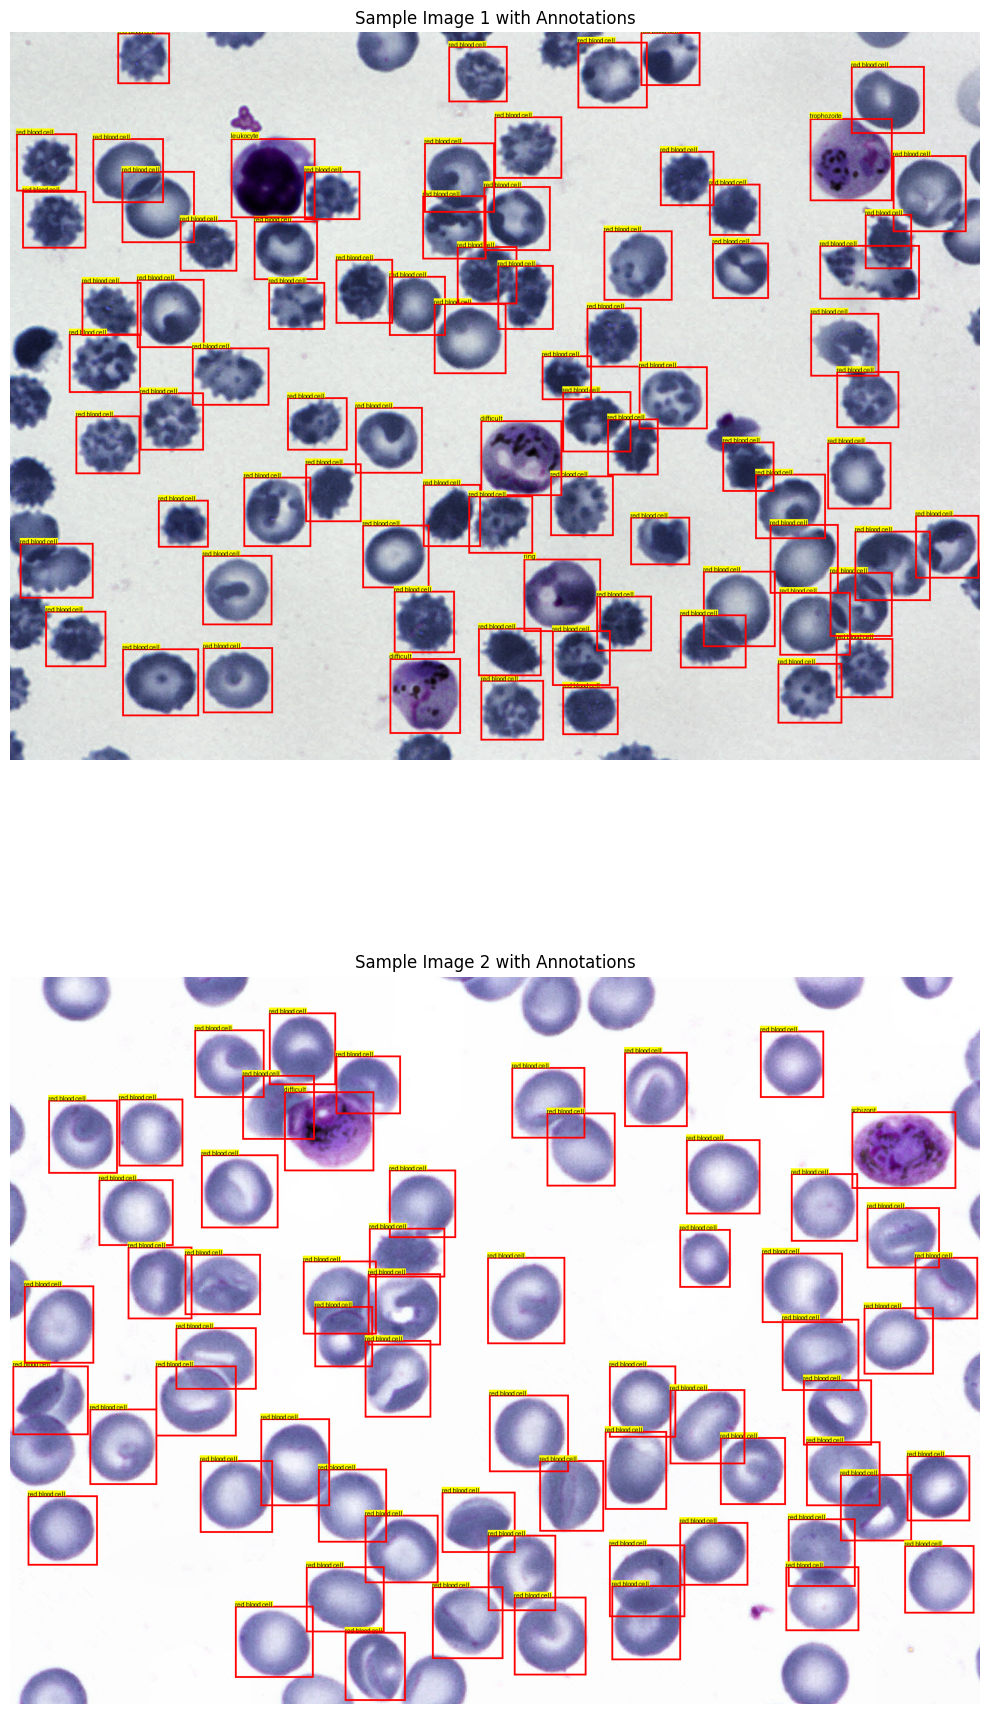

In [ ]:
# Load the training data to get image paths and annotations
train_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train/train.json' # Updated path
try:
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)
except FileNotFoundError:
    print(f"Error: The file {train_json_path} was not found.")
    train_data = []
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {train_json_path}. Please check the file format.")
    train_data = []
except Exception as e:
    print(f"An error occurred: {e}")
    train_data = []


# Select 2 random entries from the training data
num_images_to_display = 2
if len(train_data) >= num_images_to_display:
    sample_entries = random.sample(train_data, num_images_to_display)
else:
    sample_entries = train_data
    num_images_to_display = len(sample_entries)


image_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images/train'

plt.figure(figsize=(10, 10 * num_images_to_display)) # Adjust figure size for vertical layout

for i, entry in enumerate(sample_entries):
    image_pathname = os.path.basename(entry['image']['pathname']) # Get just the filename
    # Construct the full image path by joining the corrected base directory and the filename
    image_path = os.path.join(image_dir, image_pathname)


    try:
        img = Image.open(image_path).convert("RGB") # Convert to RGB to ensure compatibility with drawing
        draw = ImageDraw.Draw(img)

        # Draw bounding boxes and labels
        for obj in entry['objects']:
            bbox = obj['bounding_box']
            category = obj['category']
            # The JSON uses 'c' for column (x) and 'r' for row (y)
            # PIL's bounding box is (x_min, y_min, x_max, y_max)
            x_min = bbox['minimum']['c']
            y_min = bbox['minimum']['r']
            x_max = bbox['maximum']['c']
            y_max = bbox['maximum']['r']

            # Draw rectangle
            draw.rectangle([(x_min, y_min), (x_max, y_max)], outline="red", width=3)

            # Draw label background
            text_color = "black"
            box_color = "yellow"
            try:
                # Attempt to use a common font
                font = ImageFont.truetype("arial.ttf", 20)
            except IOError:
                # Fallback to default PIL font if arial.ttf is not available
                font = ImageFont.load_default()


            # Use textbbox instead of textsize
            text_bbox = draw.textbbox((x_min, y_min), category, font=font)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]

            text_box_coords = [(x_min, y_min - text_height), (x_min + text_width, y_min)]
            draw.rectangle(text_box_coords, fill=box_color)

            # Draw label text
            draw.text((x_min, y_min - text_height), category, fill=text_color, font=font)


        plt.subplot(num_images_to_display, 1, i + 1) # display one image per row
        plt.imshow(img)
        plt.title(f"Sample Image {i+1} with Annotations")
        plt.axis('off') # Hide axes for cleaner image display

    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
    except Exception as e:
        print(f"An error occurred while processing image {image_path}: {e}")

plt.tight_layout()
plt.show()

### **1.5.5 Check for mislabelled images**

In [ ]:
# check distribution of classes in train images
# Assuming train_data is already available from a previous cell's execution
# If not, load it first
if 'train_data' not in locals():
    train_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train/train.json' # Updated path
    try:
        with open(train_json_path, 'r') as f:
            train_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {train_json_path} was not found. Cannot analyze class distribution.")
        train_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {train_json_path}. Cannot analyze class distribution.")
        train_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        train_data = []


# Collect all object categories
categories_list = []
for entry in train_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Unique labels found in train dataset:", sorted(set(categories_list)))

# If you expect only these categories:
expected_labels = {'difficult','gametocyte','leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite'}

# Check for unexpected labels
unexpected = [c for c in sorted(set(categories_list)) if c not in expected_labels]
if unexpected:
    print("Found unexpected or misspelled categories:", unexpected)
else:
    print("All labels match expected categories.")

Unique labels found in train dataset: ['difficult', 'gametocyte', 'leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite']
All labels match expected categories.


In [ ]:
# check distribution of classes in test images
# Assuming test_data is already available from a previous cell's execution
# If not, load it first
if 'test_data' not in locals():
    test_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/test.json' # Updated path
    try:
        with open(test_json_path, 'r') as f:
            test_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {test_json_path} was not found. Cannot analyze class distribution.")
        test_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {test_json_path}. Cannot analyze class distribution.")
        test_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        test_data = []

# Collect all object categories
categories_list = []
for entry in test_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Unique labels found in test dataset:", sorted(set(categories_list)))


# If you expect only these categories:
expected_labels = {'difficult','gametocyte','leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite'}

# Check for unexpected labels
unexpected = [c for c in sorted(set(categories_list)) if c not in expected_labels]
if unexpected:
    print("Found unexpected or misspelled categories:", unexpected)
else:
    print("All labels match expected categories.")

Unique labels found in test dataset: ['difficult', 'gametocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite']
All labels match expected categories.


In [ ]:
# check distribution of classes in validation images
# Assuming val_data is already available from a previous cell's execution
# If not, load it first
if 'val_data' not in locals():
    val_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/val/val.json' # Correct path for val.json
    try:
        with open(val_json_path, 'r') as f:
            val_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {val_json_path} was not found. Cannot analyze class distribution.")
        val_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {val_json_path}. Please check the file format.")
        val_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        val_data = []

# Collect all object categories
categories_list = []
for entry in val_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Unique labels found in validation dataset:", sorted(set(categories_list)))


# If you expect only these categories:
expected_labels = {'difficult','gametocyte','leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite'}

# Check for unexpected labels
unexpected = [c for c in sorted(set(categories_list)) if c not in expected_labels]
if unexpected:
    print("Found unexpected or misspelled categories:", unexpected)
else:
    print("All labels match expected categories.")

Unique labels found in validation dataset: ['difficult', 'gametocyte', 'leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite']
All labels match expected categories.


### **1.5.6 Check for any bounding box issues**

In [ ]:
bad_boxes = []

for img_data in test_data:
    img_name = os.path.basename(img_data["image"]["pathname"])
    w = img_data["image"]["shape"]["c"]
    h = img_data["image"]["shape"]["r"]
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        xmin, ymin = box["minimum"]["c"], box["minimum"]["r"]
        xmax, ymax = box["maximum"]["c"], box["maximum"]["r"]
        if xmin >= xmax or ymin >= ymax:
            bad_boxes.append((img_name, "zero or negative box size"))
        elif xmin < 0 or ymin < 0 or xmax > w or ymax > h:
            bad_boxes.append((img_name, "box outside image bounds"))

print(f" Found {len(bad_boxes)} bounding box issues in test data.")
if bad_boxes:
    for i, (img, issue) in enumerate(bad_boxes[:10]):
        print(f"{i+1}. {img} → {issue}")

 Found 0 bounding box issues in test data.


In [ ]:
bad_boxes = []

for img_data in train_data:
    img_name = os.path.basename(img_data["image"]["pathname"])
    w = img_data["image"]["shape"]["c"]
    h = img_data["image"]["shape"]["r"]
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        xmin, ymin = box["minimum"]["c"], box["minimum"]["r"]
        xmax, ymax = box["maximum"]["c"], box["maximum"]["r"]
        if xmin >= xmax or ymin >= ymax:
            bad_boxes.append((img_name, "zero or negative box size"))
        elif xmin < 0 or ymin < 0 or xmax > w or ymax > h:
            bad_boxes.append((img_name, "box outside image bounds"))

print(f" Found {len(bad_boxes)} bounding box issues in train data.")
if bad_boxes:
    for i, (img, issue) in enumerate(bad_boxes[:10]):
        print(f"{i+1}. {img} → {issue}")

 Found 0 bounding box issues in train data.


In [ ]:
# Check for bounding box issues in validation data
bad_boxes = []

# Assuming val_data is available from previous cell executions
if 'val_data' not in locals():
    val_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/val/val.json' # Correct path for val.json
    try:
        with open(val_json_path, 'r') as f:
            val_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {val_json_path} was not found. Cannot check for bounding box issues.")
        val_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {val_json_path}. Please check the file format.")
        val_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot check for bounding box issues.")
        val_data = []


for img_data in val_data:
    img_name = os.path.basename(img_data["image"]["pathname"])
    # Need to get image dimensions from the image file for validation data
    # Since the JSON doesn't store shape directly for validation images after moving
    image_path = os.path.join('/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images/val', img_name)
    try:
        with Image.open(image_path) as img:
            w, h = img.size
    except FileNotFoundError:
        print(f"Warning: Image file not found for {img_name} at {image_path}. Cannot validate its bounding boxes.")
        continue # Skip this image if file not found
    except Exception as e:
        print(f"Error opening image file {image_path}: {e}. Cannot validate its bounding boxes.")
        continue


    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        xmin, ymin = box["minimum"]["c"], box["minimum"]["r"]
        xmax, ymax = box["maximum"]["c"], box["maximum"]["r"]
        if xmin >= xmax or ymin >= ymax:
            bad_boxes.append((img_name, "zero or negative box size"))
        elif xmin < 0 or ymin < 0 or xmax > w or ymax > h:
            bad_boxes.append((img_name, "box outside image bounds"))

print(f" Found {len(bad_boxes)} bounding box issues in validation data.")
if bad_boxes:
    for i, (img, issue) in enumerate(bad_boxes[:10]):
        print(f"{i+1}. {img} → {issue}")

 Found 0 bounding box issues in validation data.


### **1.5.7 Detect duplicate boxes on the same objec**t

In [ ]:
duplicates = []
for img_data in train_data:
    seen = set()
    img_name = os.path.basename(img_data["image"]["pathname"])
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        coords = (
            box["minimum"]["c"], box["minimum"]["r"],
            box["maximum"]["c"], box["maximum"]["r"]
        )
        if coords in seen:
            duplicates.append(img_name)
        else:
            seen.add(coords)

duplicates = list(set(duplicates))
print(f" Found {len(duplicates)} images with duplicate bounding boxes in train subset.")
if duplicates:
    print("Examples:", duplicates[:10])

 Found 0 images with duplicate bounding boxes in train subset.


In [ ]:
duplicates = []
for img_data in test_data:
    seen = set()
    img_name = os.path.basename(img_data["image"]["pathname"])
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        coords = (
            box["minimum"]["c"], box["minimum"]["r"],
            box["maximum"]["c"], box["maximum"]["r"]
        )
        if coords in seen:
            duplicates.append(img_name)
        else:
            seen.add(coords)

duplicates = list(set(duplicates))
print(f" Found {len(duplicates)} images with duplicate bounding boxes in test subset.")
if duplicates:
    print("Examples:", duplicates[:10])

 Found 0 images with duplicate bounding boxes in test subset.


In [ ]:
duplicates = []
for img_data in val_data:
    seen = set()
    img_name = os.path.basename(img_data["image"]["pathname"])
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        coords = (
            box["minimum"]["c"], box["minimum"]["r"],
            box["maximum"]["c"], box["maximum"]["r"]
        )
        if coords in seen:
            duplicates.append(img_name)
        else:
            seen.add(coords)

duplicates = list(set(duplicates))
print(f" Found {len(duplicates)} images with duplicate bounding boxes in val subset.")
if duplicates:
    print("Examples:", duplicates[:10])

 Found 0 images with duplicate bounding boxes in val subset.


### **1.5.8 Check for class imbalance**

Object category distribution in training data:
Counter({'red blood cell': 60179,
         'trophozoite': 1123,
         'difficult': 345,
         'ring': 288,
         'schizont': 136,
         'gametocyte': 107,
         'leukocyte': 78})


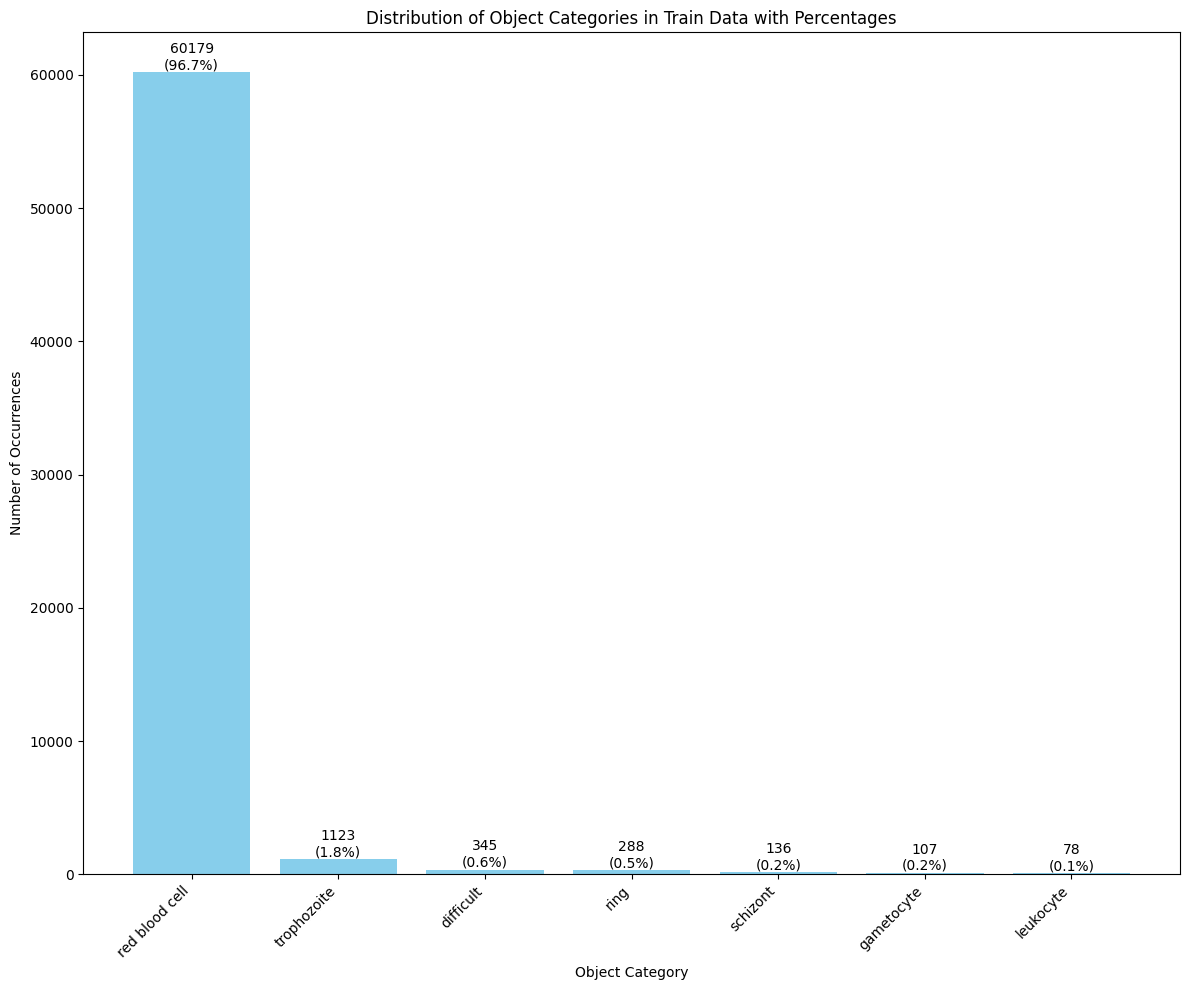

In [ ]:
# check distribution of classes in train images
# Assuming train_data is already available from a previous cell's execution
# If not, load it first
if 'train_data' not in locals():
    train_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train/train.json'
    try:
        with open(train_json_path, 'r') as f:
            train_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {train_json_path} was not found. Cannot analyze class distribution.")
        train_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {train_json_path}. Cannot analyze class distribution.")
        train_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        train_data = []


# Collect all object categories
categories_list = []
for entry in train_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Object category distribution in training data:")
pprint(category_counts)

# Sort categories and counts in descending order of counts
sorted_counts = dict(category_counts.most_common())
categories = list(sorted_counts.keys())
counts = list(sorted_counts.values())

# Calculate total count for percentages
total_count = sum(counts)

# Create a bar plot
plt.figure(figsize=(12, 10))
bars = plt.bar(categories, counts, color='skyblue')
plt.xlabel("Object Category")
plt.ylabel("Number of Occurrences")
plt.title("Distribution of Object Categories in Train Data with Percentages")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

# Add text annotations for counts and percentages
for bar in bars:
    yval = bar.get_height()
    percentage = (yval / total_count) * 100 if total_count > 0 else 0
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval}\n({percentage:.1f}%)',
             va='bottom', ha='center', rotation=0, fontsize=10) # Adjust va, ha, rotation, and fontsize as needed

plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

**Red blood cells** are the most frequent category, making up a very large percentage of the total objects.

The next most frequent category is **trophozoite**, but its count is significantly lower than that of red blood cells.

The remaining categories, including difficult, ring, schizont, gametocyte, and leukocyte, have much lower counts compared to red blood cells and trophozoites.

There is **imbalance in the dataset** at the object level with a disproportionately high number of red blood cells compared to the other categories, especially the different stages of the malaria parasite (trophozoite, ring, schizont, gametocyte). Therefore this imbalance will have to be handled before model training to ensure the model can effectively detect the less frequent classes.

A combination of data augmentation and use of weighted loss function or Focal Loss will likely be effective strategies.

Object category distribution in testing data:
Counter({'red blood cell': 5614,
         'ring': 169,
         'trophozoite': 111,
         'gametocyte': 12,
         'schizont': 11,
         'difficult': 5})


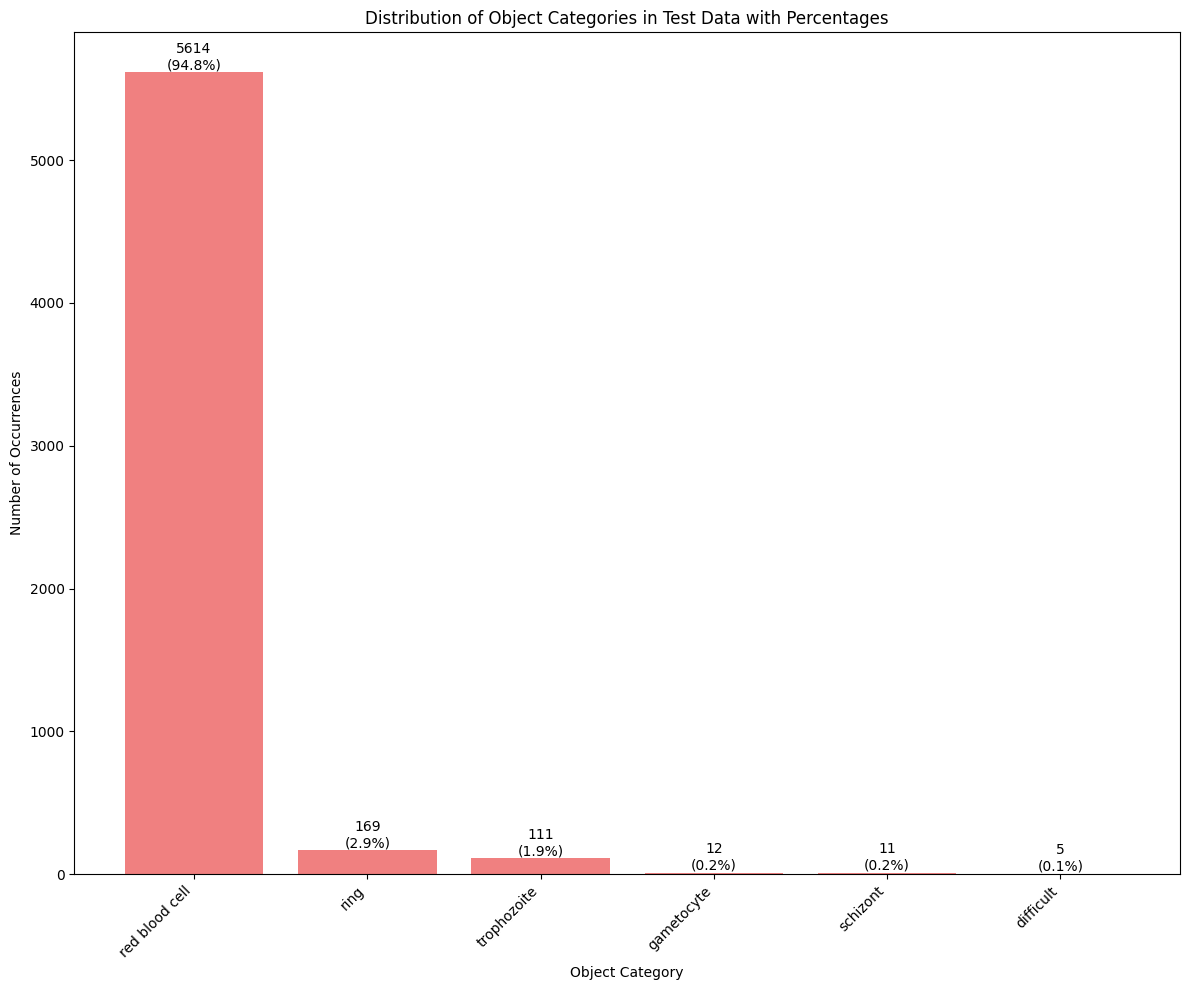

In [ ]:
# Assuming test_data is already available from a previous cell's execution
# If not, load it first
if 'test_data' not in locals():
    test_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/test.json'
    try:
        with open(test_json_path, 'r') as f:
            test_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {test_json_path} was not found. Cannot analyze class distribution.")
        test_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {test_json_path}. Cannot analyze class distribution.")
        test_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        test_data = []

# Collect all object categories
categories_list = []
for entry in test_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Object category distribution in testing data:")
pprint(category_counts)

# Optional: Create a bar plot for test data distribution
if category_counts:
    # Sort categories and counts in descending order of counts
    sorted_counts = dict(category_counts.most_common())
    categories = list(sorted_counts.keys())
    counts = list(sorted_counts.values())

    # Calculate total count for percentages
    total_count = sum(counts)

    plt.figure(figsize=(12, 10))
    bars = plt.bar(categories, counts, color='lightcoral')
    plt.xlabel("Object Category")
    plt.ylabel("Number of Occurrences")
    plt.title("Distribution of Object Categories in Test Data with Percentages")
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

    # Add text annotations for counts and percentages
    for bar in bars:
        yval = bar.get_height()
        percentage = (yval / total_count) * 100 if total_count > 0 else 0
        plt.text(bar.get_x() + bar.get_width()/2, yval,
                 f'{yval}\n({percentage:.1f}%)',
                 va='bottom', ha='center', rotation=0, fontsize=10) # Adjust va, ha, rotation, and fontsize as needed

    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()
else:
    print("No object categories found in test data to plot.")

The plot for the test data distribution, similar to the training data, shows a significant class imbalance.

Red blood cells are the most numerous category by a large margin, similar to the training data.
The counts for the other categories (ring, trophozoite, gametocyte, schizont, and difficult) are considerably lower than that of red blood cells.
The malaria parasite stages (ring, trophozoite, gametocyte, and schizont) are minority classes in the test set as well.
The category 'leukocyte' is present in the training data but appears to be absent in the test data, or its count is very low (it's not shown in the plotted categories, likely due to having 0 or very few instances).

Object category distribution in validation data:
Counter({'red blood cell': 17241,
         'trophozoite': 350,
         'difficult': 96,
         'ring': 65,
         'schizont': 43,
         'gametocyte': 37,
         'leukocyte': 25})


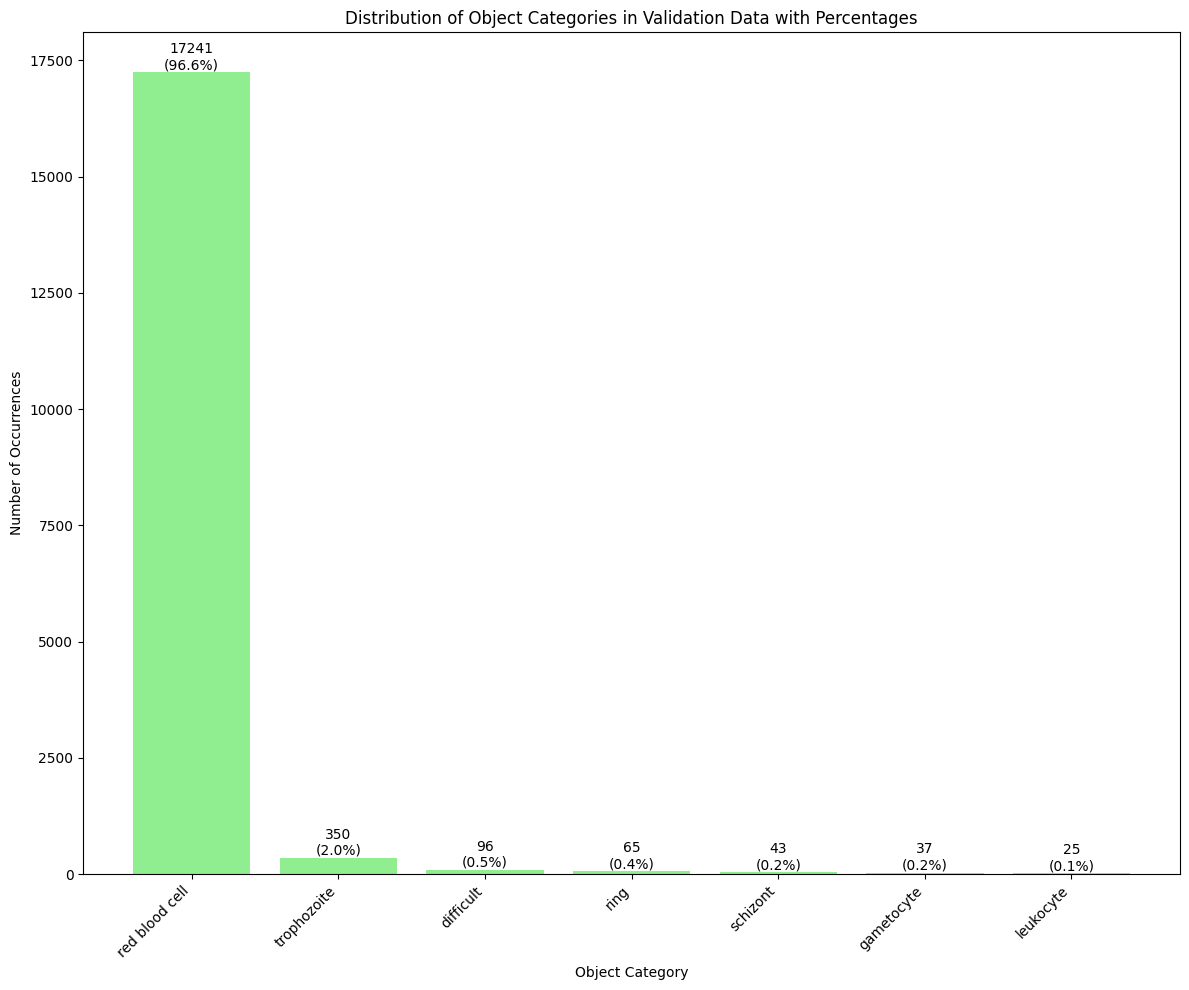

In [ ]:
# check distribution of classes in validation images
# Assuming val_data is already available from a previous cell's execution
# If not, load it first
if 'val_data' not in locals():
    val_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/val/val.json' # Correct path for val.json
    try:
        with open(val_json_path, 'r') as f:
            val_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {val_json_path} was not found. Cannot analyze class distribution.")
        val_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {val_json_path}. Please check the file format.")
        val_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        val_data = []

# Collect all object categories
categories_list = []
for entry in val_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Object category distribution in validation data:")
pprint(category_counts)

# Optional: Create a bar plot for validation data distribution
if category_counts:
    # Sort categories and counts in descending order of counts
    sorted_counts = dict(category_counts.most_common())
    categories = list(sorted_counts.keys())
    counts = list(sorted_counts.values())

    # Calculate total count for percentages
    total_count = sum(counts)

    plt.figure(figsize=(12, 10))
    bars = plt.bar(categories, counts, color='lightgreen')
    plt.xlabel("Object Category")
    plt.ylabel("Number of Occurrences")
    plt.title("Distribution of Object Categories in Validation Data with Percentages")
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

    # Add text annotations for counts and percentages
    for bar in bars:
        yval = bar.get_height()
        percentage = (yval / total_count) * 100 if total_count > 0 else 0
        plt.text(bar.get_x() + bar.get_width()/2, yval,
                 f'{yval}\n({percentage:.1f}%)',
                 va='bottom', ha='center', rotation=0, fontsize=10) # Adjust va, ha, rotation, and fontsize as needed

    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()
else:
    print("No object categories found in validation data to plot.")

same comment as for test and train data

## **1.6 Data preprocessing**

### **1.6.1 Augmentations**

Since an image can contain more than one object/category, augmentation will have to be **targeted instance-level augmentation** and not image level. If image level augmentation is done, there will be duplication of red blood cells(common object), and not the rare objects/instances and the imbalance between object types inside the images will remain.

Strategy to be employed is:
1. Cut-Paste Augmentation - Crop out annotated rare-class objects (e.g. trophozoite, schizont) and paste them onto new backgrounds (images containing RBCs). This will increase rare parasite stages
2. Add random brightness/contrast or blur to pasted crops before insertion.
2. Synthetic mosaic composition (MixUp / Mosaic) - Combine parts of several training images into one to add context and variety


In [86]:
# 1. Identify Rare Classes
# Determine which object categories are considered "rare" based on the class distribution analysis.

# Assuming category_counts (from train data analysis) is available from a previous cell's execution
# If not, load train_data and calculate it first
if 'category_counts' not in locals():
    train_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train/train.json'
    try:
        with open(train_json_path, 'r') as f:
            train_data = json.load(f)
        categories_list = []
        for entry in train_data:
            for obj in entry['objects']:
                categories_list.append(obj['category'])
        category_counts = Counter(categories_list)
        print("Calculated category counts from train data.")
    except FileNotFoundError:
        print(f"Error: The file {train_json_path} was not found. Cannot identify rare classes.")
        category_counts = Counter()
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {train_json_path}. Cannot identify rare classes.")
        category_counts = Counter()
    except Exception as e:
        print(f"An error occurred: {e}. Cannot identify rare classes.")
        category_counts = Counter()


# Define the common class and rare classes based on observed distribution
common_class = 'red blood cell'
# All other classes are considered rare for augmentation purposes
rare_classes = [cat for cat in category_counts if cat != common_class]

print(f"Common class identified: {common_class}")
print(f"Rare classes identified for augmentation: {rare_classes}")

# Define target counts for augmentation (example: augment rare classes to a certain number)
# These numbers can be adjusted based on the desired level of augmentation
# Best overall trade-off: reasonable compute, solid class balance (~1:5 ratio).
target_counts = {
    'red blood cell': category_counts.get('red blood cell', 0), # Keep common class count as is
    'trophozoite': 3000,
    'difficult': 2000,
    'ring': 2000,
    'schizont': 2000,
    'gametocyte': 2000,
    'leukocyte': 2000
}

print("\nTarget counts for augmentation:")
pprint(target_counts)

# Store rare classes for subsequent steps
rare_classes_list = rare_classes

Common class identified: red blood cell
Rare classes identified for augmentation: ['difficult', 'gametocyte', 'schizont', 'trophozoite', 'ring', 'leukocyte']

Target counts for augmentation:
{'difficult': 2000,
 'gametocyte': 2000,
 'leukocyte': 2000,
 'red blood cell': 17241,
 'ring': 2000,
 'schizont': 2000,
 'trophozoite': 3000}


In [87]:
# Step 2: Select Background Images

# Assuming train_data is available from a previous cell's execution
# If not, load it first
if 'train_data' not in locals():
    train_json_path = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train/train.json'
    try:
        with open(train_json_path, 'r') as f:
            train_data = json.load(f)
        print("Loaded train_data for background selection.")
    except FileNotFoundError:
        print(f"Error: The file {train_json_path} was not found. Cannot select background images.")
        train_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {train_json_path}. Cannot select background images.")
        train_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot select background images.")
        train_data = []

# Assuming common_class is defined from previous step (Identifying Rare Classes)
if 'common_class' not in locals():
    common_class = 'red blood cell'
    print(f"Assuming common_class is: {common_class}")


background_images = []
image_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images/train'

if train_data:
    print(f"\nSelecting background images from {len(train_data)} training images...")
    for entry in train_data:
        # Check if the image contains the common class
        contains_common_class = any(obj['category'] == common_class for obj in entry.get('objects', []))

        # If the image contains the common class, add its path to the background list
        if contains_common_class:
            image_pathname = os.path.basename(entry['image']['pathname'])
            full_image_path = os.path.join(image_dir, image_pathname)
            background_images.append(full_image_path)

    print(f"Selected {len(background_images)} images containing '{common_class}' as potential backgrounds.")

else:
    print("No training data available to select background images.")

# Store the list of background image paths for the next steps
background_image_paths = background_images


Selecting background images from 939 training images...
Selected 939 images containing 'red blood cell' as potential backgrounds.


In [88]:
# Step 3: Implement Cut-Paste Logic

from PIL import ImageEnhance, ImageFilter, Image
import random # Ensure random is imported

def calculate_iou(box1, box2):
    """
    Calculates the Intersection over Union (IoU) of two bounding boxes.

    Args:
        box1 (dict): Dictionary with 'minimum' and 'maximum' keys for the first box.
        box2 (dict): Dictionary with 'minimum' and 'maximum' keys for the second box.

    Returns:
        float: The IoU value.
    """
    # Get the coordinates of the intersection rectangle
    x_min_inter = max(box1['minimum']['c'], box2['minimum']['c'])
    y_min_inter = max(box1['minimum']['r'], box2['minimum']['r'])
    x_max_inter = min(box1['maximum']['c'], box2['maximum']['c'])
    y_max_inter = min(box1['maximum']['r'], box2['maximum']['r'])

    # Calculate the area of the intersection rectangle
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # Calculate the area of both bounding boxes
    box1_area = (box1['maximum']['c'] - box1['minimum']['c']) * (box1['maximum']['r'] - box1['minimum']['r'])
    box2_area = (box2['maximum']['c'] - box2['minimum']['c']) * (box2['maximum']['r'] - box2['minimum']['r'])

    # Calculate the area of the union
    union_area = box1_area + box2_area - inter_area

    # Avoid division by zero
    if union_area == 0:
        return 0.0

    # Calculate IoU
    iou = inter_area / union_area
    return iou


def paste_object(background_img, object_crop, background_annotations, object_category, iou_threshold=0.2):
    """
    Pastes an object crop onto a background image and updates annotations,
    attempting a more seamless paste using a simple alpha mask and checking for overlap.

    Args:
        background_img (PIL.Image.Image): The background image.
        object_crop (PIL.Image.Image): The image containing the object to paste.
        background_annotations (list): List of existing annotations for the background image.
        object_category (str): The category of the object being pasted.
        iou_threshold (float): The maximum allowed IoU with existing objects to consider a location valid.

    Returns:
        tuple: A tuple containing:
            - augmented_img (PIL.Image.Image): The augmented image.
            - updated_annotations (list): The updated list of annotations.
            - success (bool): True if pasting was successful, False otherwise.
    """
    bg_w, bg_h = background_img.size
    obj_w, obj_h = object_crop.size

    # Simple check to ensure the object crop is smaller than the background
    if obj_w > bg_w or obj_h > bg_h:
        # print("Warning: Object crop is larger than background image. Skipping paste.")
        return background_img, background_annotations, False

    # Try multiple random locations to find one with low overlap
    max_attempts = 10
    for _ in range(max_attempts):
        # Randomly determine paste location
        # Ensure the pasted object is fully within the background boundaries
        max_x = bg_w - obj_w
        max_y = bg_h - obj_h

        if max_x < 0 or max_y < 0:
            # print("Warning: Cannot paste object. Background is too small.")
            return background_img, background_annotations, False

        paste_x = random.randint(0, max_x)
        paste_y = random.randint(0, max_y)

        # Define the bounding box for the potential new object
        new_bbox_coords = {
            'minimum': {'c': paste_x, 'r': paste_y},
            'maximum': {'c': paste_x + obj_w, 'r': paste_y + obj_h}
        }

        # Check for overlap with existing bounding boxes
        overlap = False
        for existing_obj in background_annotations:
            existing_bbox = existing_obj['bounding_box']
            iou = calculate_iou(new_bbox_coords, existing_bbox)
            if iou > iou_threshold:
                overlap = True
                break # Found significant overlap, try another location

        if not overlap:
            # Found a suitable location with low overlap
            break
    else:
        # Could not find a suitable location after max_attempts
        # print(f"Warning: Could not find a suitable paste location with IoU < {iou_threshold} after {max_attempts} attempts. Skipping paste.")
        return background_img, background_annotations, False


    # Apply variations to the object crop (brightness, contrast, blur)
    augmented_object_crop = object_crop.copy()

    # Random brightness
    if random.random() < 0.5: # 50% chance of applying brightness change
        enhancer = ImageEnhance.Brightness(augmented_object_crop)
        augmented_object_crop = enhancer.enhance(random.uniform(0.8, 1.2)) # Adjust brightness by -20% to +20%

    # Random contrast
    if random.random() < 0.5: # 50% chance of applying contrast change
        enhancer = ImageEnhance.Contrast(augmented_object_crop)
        augmented_object_crop = enhancer.enhance(random.uniform(0.8, 1.2)) # Adjust contrast by -20% to +20%

    # Random blur
    if random.random() < 0.2: # 20% chance of applying blur
         augmented_object_crop = augmented_object_crop.filter(ImageFilter.GaussianBlur(radius=random.uniform(0, 1.5))) # Apply slight blur

    # --- Basic Masking Approach ---
    # Create a simple alpha mask based on the bounding box of the object crop.
    # This assumes the object fills the bounding box, which may not be true.
    mask = Image.new('L', (obj_w, obj_h), 255) # Fully opaque mask

    # Convert object crop to RGBA to include the alpha channel
    if augmented_object_crop.mode != 'RGBA':
        augmented_object_crop = augmented_object_crop.convert('RGBA')

    # Paste the object onto the background using the mask
    augmented_img = background_img.copy().convert('RGBA') # Ensure background is RGBA for alpha blending
    augmented_img.paste(augmented_object_crop, (paste_x, paste_y), mask)
    augmented_img = augmented_img.convert('RGB') # Convert back to RGB if needed later


    # Update annotations
    updated_annotations = background_annotations.copy()
    updated_annotations.append({'bounding_box': new_bbox_coords, 'category': object_category})

    return augmented_img, updated_annotations, True

# Note: This is a basic implementation using an approximate mask. More advanced techniques could involve
# using actual segmentation masks if available, ensuring pasted objects are
# not too close to the edges, or using more sophisticated blending techniques.

Extracted an example crop of category: schizont

Successfully pasted object onto background.
Number of annotations after pasting: 1


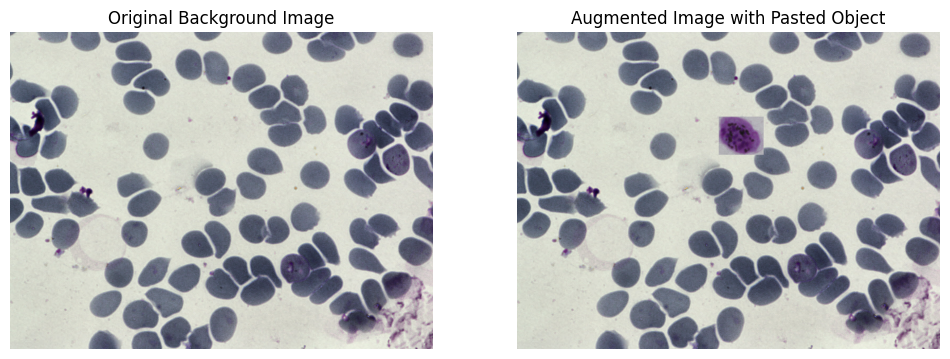

In [ ]:
# Step 4: Generate Augmented Images and Annotations

# Assuming train_data, rare_classes_list, target_counts, background_image_paths are available
# from previous steps.

if 'train_data' not in locals() or 'rare_classes_list' not in locals() or \
   'target_counts' not in locals() or 'background_image_paths' not in locals() or \
   not train_data or not rare_classes_list or not target_counts or not background_image_paths:
    print("Error: Required data from previous steps is missing. Please run the preceding cells.")
else:
    print("Starting image augmentation...")

    augmented_data = [] # List to store data for augmented images
    original_train_data = train_data.copy() # Keep a copy of original train data

    # Create a dictionary to store rare object crops by category
    rare_object_crops = defaultdict(list)

    print("Extracting rare object crops...")
    image_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/images/train'
    for entry in original_train_data:
        image_pathname = os.path.basename(entry['image']['pathname'])
        full_image_path = os.path.join(image_dir, image_pathname)
        try:
            original_img = Image.open(full_image_path).convert("RGB")
            for obj in entry['objects']:
                if obj['category'] in rare_classes_list:
                    bbox = obj['bounding_box']
                    x_min = bbox['minimum']['c']
                    y_min = bbox['minimum']['r']
                    x_max = bbox['maximum']['c']
                    y_max = bbox['maximum']['r']

                    # Ensure bounding box is within image boundaries before cropping
                    img_w, img_h = original_img.size
                    if 0 <= x_min < x_max <= img_w and 0 <= y_min < y_max <= img_h:
                         rare_object_crop = original_img.crop((x_min, y_min, x_max, y_max))
                         rare_object_crops[obj['category']].append(rare_object_crop)
                    # else:
                         # print(f"Warning: Bounding box for rare object {obj['category']} in {image_pathname} is outside image bounds. Skipping crop.")

        except FileNotFoundError:
            print(f"Warning: Image file not found for crop extraction at {full_image_path}. Skipping.")
        except Exception as e:
             print(f"An error occurred while extracting rare object crop from {full_image_path}: {e}")


    print("Rare object crops extracted.")
    for category, crops in rare_object_crops.items():
        print(f"  - {category}: {len(crops)} crops")


    print("\nGenerating augmented images...")

    # Calculate current counts of rare classes in original data
    current_rare_counts = Counter()
    for entry in original_train_data:
        for obj in entry['objects']:
            if obj['category'] in rare_classes_list:
                current_rare_counts[obj['category']] += 1

    augmented_images_count = 0
    # Iterate through rare classes and generate augmented images
    for rare_class in rare_classes_list:
        needed_count = target_counts.get(rare_class, 0) - current_rare_counts.get(rare_class, 0)

        if needed_count <= 0 or not rare_object_crops[rare_class]:
            print(f"  - No augmentation needed or no crops available for {rare_class}.")
            continue

        print(f"  - Augmenting {rare_class} (needed: {needed_count})")

        # Generate augmented images for the current rare class
        generated_count = 0
        max_attempts_per_augmentation = 10 # Limit attempts to find a suitable paste location

        while generated_count < needed_count:
            # Select a random rare object crop of the current class
            if not rare_object_crops[rare_class]:
                print(f"    Warning: No more crops available for {rare_class}. Stopping augmentation for this class.")
                break
            object_crop = random.choice(rare_object_crops[rare_class])

            # Select a random background image
            background_image_path = random.choice(background_image_paths)

            try:
                background_img = Image.open(background_image_path).convert("RGB")

                # Find the original annotations for the selected background image
                # This requires iterating through the original train_data to find the matching entry
                background_annotations = []
                background_filename = os.path.basename(background_image_path)
                for entry in original_train_data:
                    if os.path.basename(entry['image']['pathname']) == background_filename:
                        background_annotations = entry.get('objects', [])
                        break # Found the annotations

                # Attempt to paste the object
                augmented_img, updated_annotations, success = paste_object(
                    background_img,
                    object_crop,
                    background_annotations,
                    rare_class,
                    iou_threshold=0.2 # Use a reasonable IoU threshold
                )

                if success:
                    # Create a unique filename for the augmented image
                    original_filename = os.path.basename(background_image_path)
                    # Add a unique identifier to the filename
                    augmented_filename = f"augmented_{rare_class}_{generated_count}_{original_filename}"
                    augmented_image_path = os.path.join(image_dir, augmented_filename) # Save augmented images in the train image directory

                    # Save the augmented image
                    augmented_img.save(augmented_image_path)

                    # Create a new entry for the augmented data
                    augmented_entry = {
                        'image': {
                            'checksum': '', # Checksum can be calculated later if needed
                            'pathname': f'/images/train/{augmented_filename}', # Path relative to the dataset root
                            'shape': {'c': augmented_img.size[0], 'r': augmented_img.size[1], 'channels': 3}
                        },
                        'objects': updated_annotations
                    }
                    augmented_data.append(augmented_entry)
                    generated_count += 1
                    augmented_images_count += 1
                    # print(f"    Generated augmented image {generated_count}/{needed_count}")
                # else:
                    # print(f"    Paste attempt failed (overlap or other issue). Attempt: {attempt + 1}/{max_attempts_per_augmentation}")

            except FileNotFoundError:
                print(f"    Warning: Background image file not found at {background_image_path}. Skipping augmentation attempt.")
            except Exception as e:
                print(f"    An error occurred during augmentation attempt with {background_image_path}: {e}")

    print(f"\nImage augmentation complete. Generated {augmented_images_count} augmented images.")

    # Combine original and augmented data
    final_train_data = original_train_data + augmented_data
    print(f"Total entries in the new training data: {len(final_train_data)}")

    # Store the final_train_data for the next steps
    train_data = final_train_data

Starting image augmentation...
Extracting rare object crops...
Rare object crops extracted.
  - schizont: 136 crops
  - ring: 288 crops
  - trophozoite: 1123 crops
  - difficult: 345 crops
  - gametocyte: 107 crops
  - leukocyte: 78 crops

Generating augmented images...
  - Augmenting difficult (needed: 1655)
  - Augmenting gametocyte (needed: 1893)
  - Augmenting schizont (needed: 1864)
  - Augmenting trophozoite (needed: 1877)
  - Augmenting ring (needed: 1712)
  - Augmenting leukocyte (needed: 1922)


In [91]:
# Show the count of current training data after augmentation
if 'train_data' in locals():
    print(f"Current count of training data entries: {len(train_data)}")
else:
    print("Training data not available. Please run the augmentation cell first.")

Current count of training data entries: 11862


In [90]:
# Inspect the generated augmented_data list

if 'augmented_data' in locals():
    print(f"Number of entries in augmented_data: {len(augmented_data)}")

    print("\nFirst 3 entries in augmented_data:")
    if augmented_data:
        for i, entry in enumerate(augmented_data[:3]):
            print(f"\nEntry {i+1}:")
            pprint(entry)
    else:
        print("The augmented_data list is empty.")

else:
    print("augmented_data list not found. Please run the augmentation cell first.")

Number of entries in augmented_data: 10923

First 3 entries in augmented_data:

Entry 1:
{'image': {'checksum': '',
           'pathname': '/images/train/augmented_difficult_0_1d9d4dac-66f9-4c87-b714-d723d5b15fa9.png',
           'shape': {'c': 1600, 'channels': 3, 'r': 1200}},
 'objects': [{'bounding_box': {'maximum': {'c': 1004, 'r': 996},
                               'minimum': {'c': 882, 'r': 879}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 847, 'r': 1000},
                               'minimum': {'c': 719, 'r': 873}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 525, 'r': 382},
                               'minimum': {'c': 409, 'r': 256}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 991, 'r': 639},
                               'minimum': {'c': 869, 'r': 509}},
              'category': 'red blood cell'},
             {'bounding

visualize some augmented images to ensure the pasting and annotations are correct.

Checking object category distribution in the augmented training data...

Object category distribution in augmented training data:
Counter({'red blood cell': 737499,
         'trophozoite': 15941,
         'difficult': 6040,
         'ring': 5353,
         'schizont': 3563,
         'gametocyte': 3270,
         'leukocyte': 2894})

Comparison with target counts:
  - red blood cell: Current = 737499, Target = 17241
  - trophozoite: Current = 15941, Target = 3000
  - difficult: Current = 6040, Target = 2000
  - ring: Current = 5353, Target = 2000
  - schizont: Current = 3563, Target = 2000
  - gametocyte: Current = 3270, Target = 2000
  - leukocyte: Current = 2894, Target = 2000


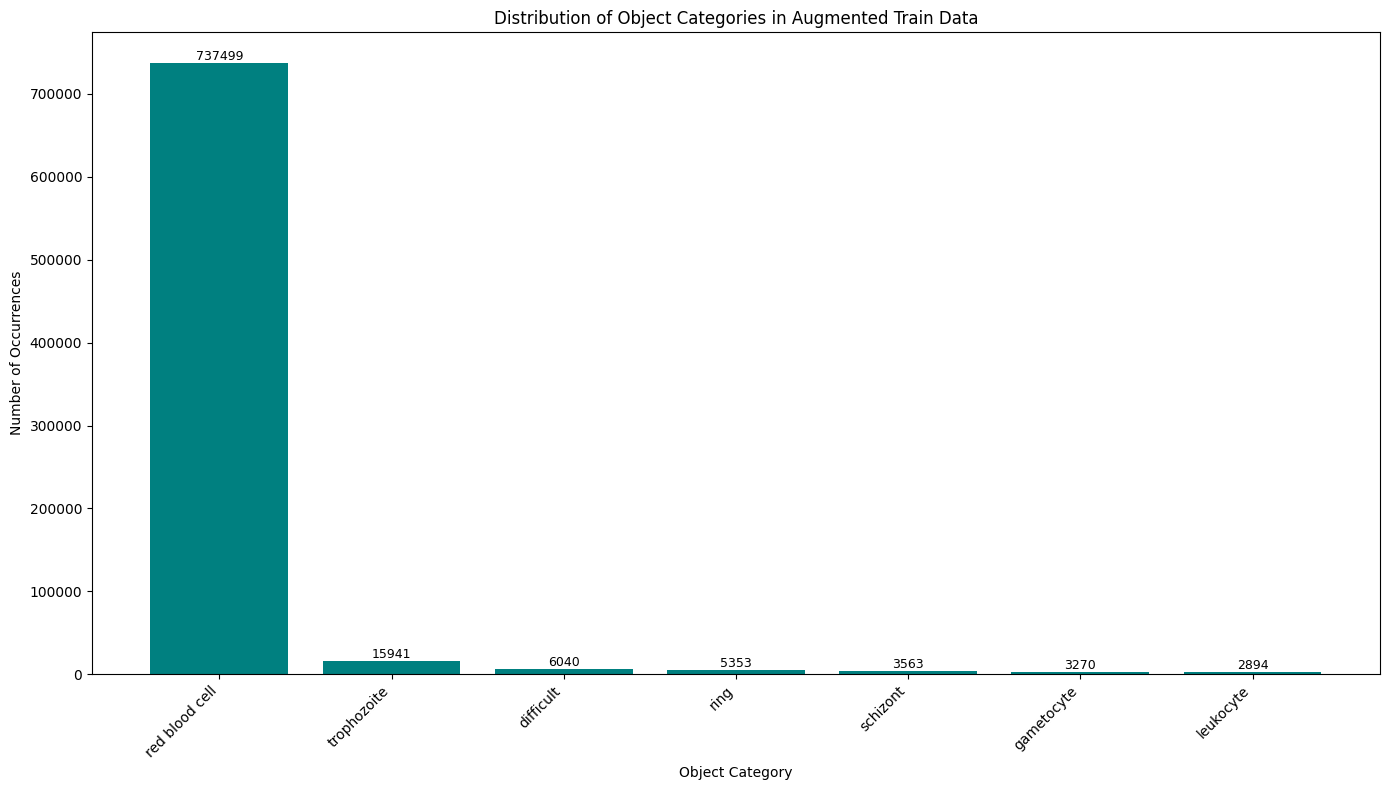

In [92]:
# Verify Augmented Data: Check Class Distribution

# Assuming train_data and target_counts are available
if 'train_data' not in locals() or not train_data:
    print("Error: Updated training data not available. Please run the augmentation cell first.")
elif 'target_counts' not in locals():
    print("Error: Target counts not available. Please run the cell that defines target_counts.")
else:
    print("Checking object category distribution in the augmented training data...")

    # Collect all object categories from the augmented training data
    augmented_categories_list = []
    for entry in train_data:
        for obj in entry.get('objects', []): # Use .get('objects', []) to handle entries without objects key
            augmented_categories_list.append(obj['category'])

    # Count the occurrences of each category
    augmented_category_counts = Counter(augmented_categories_list)

    print("\nObject category distribution in augmented training data:")
    pprint(augmented_category_counts)

    print("\nComparison with target counts:")
    for category, target_count in target_counts.items():
        current_count = augmented_category_counts.get(category, 0)
        print(f"  - {category}: Current = {current_count}, Target = {target_count}")

    # Optional: Create a bar plot for the augmented data distribution
    if augmented_category_counts:
        # Sort categories and counts in descending order of counts
        sorted_counts = dict(augmented_category_counts.most_common())
        categories = list(sorted_counts.keys())
        counts = list(sorted_counts.values())

        # Calculate total count for percentages
        total_count = sum(counts)

        plt.figure(figsize=(14, 8)) # Adjust figure size
        bars = plt.bar(categories, counts, color='teal')
        plt.xlabel("Object Category")
        plt.ylabel("Number of Occurrences")
        plt.title("Distribution of Object Categories in Augmented Train Data")
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

        # Add text annotations for counts
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval,
                     str(yval),
                     va='bottom', ha='center', rotation=0, fontsize=9) # Adjust fontsize as needed

        plt.tight_layout() # Adjust layout to prevent labels overlapping
        plt.show()
    else:
        print("No object categories found in augmented train data to plot.")

The rare classes (counts for 'trophozoite', 'difficult', 'ring', 'schizont', 'gametocyte', and 'leukocyte') are now much higher than their original counts, and in many cases have exceeded the target_counts defined. This indicates that the augmentation process successfully added instances of these rare classes.

The count of 'red blood cell' has also increased dramatically to 737,499. This is likely because each time a rare object was pasted onto a background image, the original red blood cells in that background image were retained in the annotations, leading to a multiplication of red blood cell annotations across the augmented images.

Imbalance will be controlled for during the YOLO model training

In [93]:
# Step 5: Save Augmented Data

# Assuming train_data is available and updated with augmented data
if 'train_data' not in locals() or not train_data:
    print("Error: Updated training data not available. Please run the augmentation cell first.")
else:
    # Define the path to save the updated train.json file
    base_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria'
    train_labels_dir = os.path.join(base_dir, 'labels', 'train')
    updated_train_json_path = os.path.join(train_labels_dir, 'train_augmented.json') # Save as a new file to keep original

    # Ensure the labels directory exists
    os.makedirs(train_labels_dir, exist_ok=True)

    print(f"Saving updated training data to: {updated_train_json_path}")

    try:
        with open(updated_train_json_path, 'w') as f:
            json.dump(train_data, f, indent=4)
        print("Successfully saved updated training data.")
    except Exception as e:
        print(f"Error saving updated training data: {e}")

# Note: The augmented images were saved to the training images directory in the previous step (Step 4).
# This step focuses on saving the updated annotation file.

Saving updated training data to: /content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria/labels/train/train_augmented.json
Successfully saved updated training data.


In [ ]:
# Step 1: Convert Annotations to YOLO Format

import os
import json
from PIL import Image # Import Image to get image dimensions

# Define the base directory for the dataset in Google Drive
base_dir = '/content/drive/MyDrive/malaria_dataset/malaria_extracted/malaria'

# Define paths to image and label directories
image_dirs = {
    'train': os.path.join(base_dir, 'images', 'train'),
    'val': os.path.join(base_dir, 'images', 'val'),
    'test': os.path.join(base_dir, 'images', 'test')
}

label_json_paths = {
    'train': os.path.join(base_dir, 'labels', 'train', 'train_augmented.json'), # Use the augmented train.json
    'val': os.path.join(base_dir, 'labels', 'val', 'val.json'),
    'test': os.path.join(base_dir, 'labels', 'test.json')
}

yolo_label_dirs = {
    'train': os.path.join(base_dir, 'labels', 'train'),
    'val': os.path.join(base_dir, 'labels', 'val'),
    'test': os.path.join(base_dir, 'labels', 'test')
}

# Ensure the YOLO label directories exist
for dataset_type in yolo_label_dirs:
    os.makedirs(yolo_label_dirs[dataset_type], exist_ok=True)


# Define the mapping from category name to class ID
# Ensure the order matches the desired class order for YOLOv8
class_mapping = {
    'red blood cell': 0,
    'trophozoite': 1,
    'ring': 2,
    'schizont': 3,
    'gametocyte': 4,
    'leukocyte': 5,
    'difficult': 6 # 'difficult' objects are often included but might be ignored during training/evaluation depending on configuration
}

print("Starting annotation conversion to YOLO format...")

for dataset_type, json_path in label_json_paths.items():
    print(f"\nConverting annotations for {dataset_type} dataset...")
    try:
        with open(json_path, 'r') as f:
            annotations_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Annotation file not found at {json_path}. Skipping {dataset_type} conversion.")
        continue
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {json_path}. Skipping {dataset_type} conversion.")
        continue
    except Exception as e:
        print(f"An error occurred loading {json_path}: {e}. Skipping {dataset_type} conversion.")
        continue


    image_count = 0
    for entry in annotations_data:
        image_pathname = os.path.basename(entry['image']['pathname'])
        image_path = os.path.join(image_dirs[dataset_type], image_pathname)

        # Get image dimensions
        try:
            with Image.open(image_path) as img:
                img_w, img_h = img.size
        except FileNotFoundError:
            print(f"Warning: Image file not found for {image_pathname} at {image_path}. Skipping its annotations.")
            continue
        except Exception as e:
            print(f"Error opening image file {image_path}: {e}. Skipping its annotations.")
            continue

        # Define the path for the YOLO format label file
        label_filename = os.path.splitext(image_pathname)[0] + '.txt'
        yolo_label_path = os.path.join(yolo_label_dirs[dataset_type], label_filename)

        # Write annotations to the YOLO format file
        with open(yolo_label_path, 'w') as f:
            for obj in entry.get('objects', []):
                category = obj['category']
                bbox = obj['bounding_box']

                # Get class ID
                class_id = class_mapping.get(category)
                if class_id is None:
                    print(f"Warning: Unknown category '{category}' in {image_pathname}. Skipping object.")
                    continue # Skip object if category is not in mapping

                # Get bounding box coordinates
                xmin = bbox['minimum']['c']
                ymin = bbox['minimum']['r']
                xmax = bbox['maximum']['c']
                ymax = bbox['maximum']['r']

                # Calculate YOLO format coordinates (normalized center_x, center_y, width, height)
                center_x = (xmin + xmax) / 2.0
                center_y = (ymin + ymax) / 2.0
                width = xmax - xmin
                height = ymax - ymin

                # Normalize coordinates
                # Ensure image dimensions are not zero to avoid division by zero
                if img_w > 0 and img_h > 0:
                    center_x_norm = center_x / img_w
                    center_y_norm = center_y / img_h
                    width_norm = width / img_w
                    height_norm = height / img_h

                    # Write to file in YOLO format
                    f.write(f"{class_id} {center_x_norm:.6f} {center_y_norm:.6f} {width_norm:.6f} {height_norm:.6f}\n")
                else:
                    print(f"Warning: Image {image_pathname} has zero dimensions. Cannot normalize bounding boxes. Skipping annotations for this image.")


        image_count += 1
    print(f"Converted annotations for {image_count} images in the {dataset_type} dataset.")

print("\nAnnotation conversion complete.")